In [27]:
import numpy as np
from ruamel.yaml import YAML
import itertools
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Rectangle, Polygon
from IPython.display import clear_output
import torch
import sys
import pandas as pd
import tarfile
import math
import warnings
import os
import math
import csv
import gym
import argparse
import datetime
import pandas as pd
from IPython.display import clear_output, display
import json
import copy
# import torch.optim.lr_scheduler as scheduler
from scipy.interpolate import RBFInterpolator
warnings.filterwarnings('ignore')
import settings
import torch.nn.functional as F


In [28]:
def get_data_dir(subfolder):
    current_dir = os.getcwd()
    print(current_dir)
    return os.path.join(current_dir, "experiment_data", f"{subfolder}")


In [29]:
current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

In [30]:
def derived_papi(PAPI_data):
    DERIVED = {}
    DERIVED['TOT_INS_PER_CYC'] = pd.DataFrame({
        'value': np.array(PAPI_data['PAPI_TOT_INS']['instantaneous_value']) / np.array(PAPI_data['PAPI_TOT_CYC']['instantaneous_value']),
        'timestamp': np.array(PAPI_data['PAPI_TOT_INS'].time)
    })
    DERIVED['TOT_CYC_PER_INS'] = pd.DataFrame({
        'value': np.array(PAPI_data['PAPI_TOT_CYC']['instantaneous_value']) / np.array(PAPI_data['PAPI_TOT_INS']['instantaneous_value']),
        'timestamp': np.array(PAPI_data['PAPI_TOT_CYC'].time)
    })
    DERIVED['L3_TCM_PER_TCA'] = pd.DataFrame({
        'value': np.array(PAPI_data['PAPI_L3_TCM']['instantaneous_value']) / np.array(PAPI_data['PAPI_L3_TCA']['instantaneous_value']),
        'timestamp': np.array(PAPI_data['PAPI_L3_TCM'].time)
    })  
    DERIVED['TOT_STL_PER_CYC'] = pd.DataFrame({
        'value': np.array(PAPI_data['PAPI_RES_STL']['instantaneous_value']) / np.array(PAPI_data['PAPI_TOT_CYC']['instantaneous_value']),
        'timestamp': np.array(PAPI_data['PAPI_RES_STL'].time)
    })
    
    # Create a mask for non-NaN values across all keys
    mask = ~DERIVED['TOT_INS_PER_CYC']['value'].isna()  # Start with one key to create the mask
    for key in DERIVED:
        mask &= ~DERIVED[key]['value'].isna()  # Combine masks for all keys

    for key in DERIVED:
        DERIVED[key] = DERIVED[key][mask]  # Filter each DataFrame using the combined mask

    return DERIVED

def calculate_power_with_wraparound(current, previous, time_diff, wraparound_value=262143.328850):
    diff = current - previous
    if diff < 0:  # Wraparound detected
        diff = (wraparound_value - previous) + current
    return diff / time_diff

def compute_measured_power(pubPower, all_data):
    PCAP_data = all_data['PCAP']
    first_PCAP_point = PCAP_data['timestamp'].iloc[0]
    new_pubPower = pubPower[pubPower['time'] >= first_PCAP_point] 
    elapsed_time = new_pubPower['time']-new_pubPower['time'].iloc[0]
    new_pubPower['elapsed_time'] = elapsed_time    
    new_pubPower.rename(columns={'time': 'timestamp'}, inplace=True)
    return new_pubPower

def compute_power(pubEnergy):
    power = {}
    geopm_sensor0 = geopm_sensor1 = pd.DataFrame({'timestamp':[],'value':[]})
    for i,row in pubEnergy.iterrows():
        if i%2 == 0:
            geopm_sensor0 = pd.concat([geopm_sensor0, pd.DataFrame([{'timestamp': row['time'], 'value': row['value']}])], ignore_index=True)
        else:
            geopm_sensor1 = pd.concat([geopm_sensor1, pd.DataFrame([{'timestamp': row['time'], 'value': row['value']}])], ignore_index=True)


    power['geopm_power_0'] = pd.DataFrame({
        'timestamp': geopm_sensor0['timestamp'][1:],  # Add timestamps
        'power': [
            calculate_power_with_wraparound(
                geopm_sensor0['value'][i],
                geopm_sensor0['value'][i-1],
                geopm_sensor0['timestamp'][i] - geopm_sensor0['timestamp'][i-1]
            ) for i in range(1, len(geopm_sensor0))
        ]
    })

    # Apply the same logic to geopm_power_1
    power['geopm_power_1'] = pd.DataFrame({
        'timestamp': geopm_sensor1['timestamp'][1:],  # Add timestamps
        'power': [
            calculate_power_with_wraparound(
                geopm_sensor1['value'][i],
                geopm_sensor1['value'][i-1],
                geopm_sensor1['timestamp'][i] - geopm_sensor1['timestamp'][i-1]
            ) for i in range(1, len(geopm_sensor1))
        ]
    })

    min_length = min(len(power['geopm_power_0']), len(power['geopm_power_1']))
    geopm_power_0 = power['geopm_power_0'][:min_length]
    geopm_power_1 = power['geopm_power_1'][:min_length]

    average_power = pd.DataFrame({
        'timestamp': geopm_power_0['timestamp'],  # Use the timestamp from geopm_power_0
        'average_power': [(p0 + p1) / 2 for p0, p1 in zip(geopm_power_0['power'], geopm_power_1['power'])]
    })
    average_power['elapsed_time'] = average_power['timestamp'] - average_power['timestamp'].iloc[0]
    power['average_power'] = average_power
    return power

def measure_progress(progress_data, all_data):
    power_data = all_data['measured_power']
    PCAP_data = all_data['PCAP']
    Progress_DATA = {} 
    progress_sensor = pd.DataFrame(progress_data)
    first_PCAP_point = PCAP_data['timestamp'].iloc[0]
    new_progress_sensor = progress_sensor[progress_sensor['time'] >= first_PCAP_point]
    new_power_data = power_data[power_data['timestamp'] >= first_PCAP_point]
    first_sensor_point = min(new_power_data['timestamp'].iloc[0], new_progress_sensor['time'].iloc[0])
    new_progress_sensor['elapsed_time'] = new_progress_sensor['time'] - first_sensor_point  
    performance_elapsed_time = new_progress_sensor.elapsed_time
    frequency_values = [
        progress_data['value'].iloc[t] / (performance_elapsed_time.iloc[t] - performance_elapsed_time.iloc[t-1]) for t in range(1, len(performance_elapsed_time))
    ]
    frequency_values = [0] + frequency_values  
    new_progress_sensor['frequency'] = frequency_values
    upsampled_timestamps= PCAP_data['timestamp']
    # progress_frequency_median = pd.DataFrame({'median': np.nanmedian(new_progress_sensor['frequency'].where(new_progress_sensor['time'] <= upsampled_timestamps.iloc[0])), 'timestamp': upsampled_timestamps.iloc[0]}, index=[0])
    progress_frequency_median = pd.DataFrame()
    for t in range(1, len(upsampled_timestamps)):
        progress_frequency_median = pd.concat([progress_frequency_median, pd.DataFrame({'median': [np.nanmedian(new_progress_sensor['frequency'].where((new_progress_sensor['time'] >= upsampled_timestamps.iloc[t-1]) & (new_progress_sensor['time'] <= upsampled_timestamps.iloc[t])))],
        'timestamp': [upsampled_timestamps.iloc[t]]})], ignore_index=True)
    progress_frequency_median['elapsed_time'] = progress_frequency_median['timestamp'] - progress_frequency_median['timestamp'].iloc[0]
    Progress_DATA['progress_sensor'] = new_progress_sensor
    Progress_DATA['progress_frequency_median'] = progress_frequency_median
    Progress_DATA['progress_sensor'].rename(columns={'time': 'timestamp'}, inplace=True)
    return Progress_DATA

def collect_papi(PAPI_data,all_data):
    PCAP_data = all_data['PCAP']
    first_PCAP_point = PCAP_data['timestamp'].iloc[0]
    new_PAPI_data = PAPI_data[PAPI_data['time'] >= first_PCAP_point]
    PAPI = {}
    for scope in new_PAPI_data['scope'].unique():
        scope_parts = scope.split('.')
        if len(scope_parts) > 4:  
            extracted_scope = scope_parts[3]
            PAPI[extracted_scope] = new_PAPI_data[new_PAPI_data['scope'] == scope]
            instantaneous_values = [0] + [PAPI[extracted_scope]['value'].iloc[k] - PAPI[extracted_scope]['value'].iloc[k-1] for k in range(1,len(PAPI[extracted_scope]))]
            PAPI[extracted_scope]['instantaneous_value'] = instantaneous_values
            PAPI[extracted_scope]['elapsed_time'] = PAPI[extracted_scope]['time'] - PAPI[extracted_scope]['time'].iloc[0]
    return PAPI


def generate_PCAP(PCAP_data):
    for row in PCAP_data.iterrows():
        if row[1]['time'] == 0:
            PCAP_data = PCAP_data.drop(row[0])


    PCAP_data['elapsed_time'] = PCAP_data['time'] - PCAP_data['time'].iloc[0]
    PCAP_data.rename(columns={'time': 'timestamp'}, inplace=True)
    return PCAP_data


In [31]:
DATA_DIR = get_data_dir("training_data")
root,folders,files = next(os.walk(DATA_DIR))
training_data = {}
MAX_PROGRESS = {}
for APP in folders:
    APP_DIR = os.path.join(DATA_DIR, APP)
    training_data[APP] = {}
    for file in next(os.walk(APP_DIR))[2]:
        training_data[APP][file] = {}
        if file.endswith('.tar'):
            tar_path = os.path.join(APP_DIR, file)
            extract_dir = os.path.join(APP_DIR, file[:-4])  
            
            if not os.path.exists(extract_dir):
                os.makedirs(extract_dir)
            
            with tarfile.open(tar_path, 'r') as tar:
                tar.extractall(path=extract_dir)
            
        pubProgress = pd.read_csv(f'{extract_dir}/progress.csv')
        pubEnergy = pd.read_csv(f'{extract_dir}/energy.csv')
        pubPAPI = pd.read_csv(f'{extract_dir}/papi.csv')
        pubPCAP = pd.read_csv(f'{extract_dir}/PCAP_file.csv')
        pubPower = pd.read_csv(f'{extract_dir}/measured_power.csv')
        # training_data[APP][file]['power'] = compute_power(pubEnergy)
        training_data[APP][file]['PCAP'] = generate_PCAP(pubPCAP)
        training_data[APP][file]['measured_power'] = compute_measured_power(pubPower, training_data[APP][file])
        training_data[APP][file]['progress'] = measure_progress(pubProgress,training_data[APP][file])
        training_data[APP][file]['papi'] = collect_papi(pubPAPI,training_data[APP][file])
        training_data[APP][file]['derived_papi'] = derived_papi(training_data[APP][file]['papi'])   
    MAX_PROGRESS[APP] = training_data[APP][file]['progress']['progress_frequency_median']['median'].max()


/Users/akhileshraj/Desktop/summer2024/main_codes


In [32]:
T_S = 1
ACTIONS = [78.0, 83.0, 89.0, 95.0, 101.0, 107.0, 112.0, 118.0, 124.0, 130.0, 136.0, 141.0, 147.0, 153.0, 159.0, 165.0]
exec_steps = 10000    
TOTAL_ACTIONS = len(ACTIONS)                                                                                                  # Total clock cycles needed for the execution of program.
ACTION_MIN = min(ACTIONS)                                                                                                    # Minima of control space
ACTION_MAX = max(ACTIONS)                                                                                                     # Maxima of control space
ACT_MID = ACTION_MIN + (ACTION_MAX - ACTION_MIN) / 2                                                                    # Midpoint of the control space to compute the normalized action space                     
OBS_MIN = np.zeros((5,))  
OBS_MAX = np.array([300,165,1,1,1])                                                                                 # Minima of observation space
OBS_MID = OBS_MIN + (OBS_MAX - OBS_MIN) / 2
EXEC_ITERATIONS = 10000
TOTAL_OBS = OBS_MAX - OBS_MIN
OBS_ONEHOT = 'onehot'
OBS_RANDOM = 'random'
OBS_SMOOTH = 'smooth'

def scale_reward_uniform(r, r_min=1.4666, r_max=7.7000, target_min=-10, target_max=1):
    return target_min + (r - r_min) * (target_max - target_min) / (r_max - r_min)


class SYS(object):
    def __init__(self,observation_type=OBS_ONEHOT,dim_obs=1,teps=0.0):
        super(SYS,self).__init__()

        self.num_actions = TOTAL_ACTIONS
        self.action_space = gym.spaces.Discrete(len(ACTIONS))  
        self.actions = ACTIONS  
        self.observation_space = gym.spaces.Box(low=OBS_MIN, high=OBS_MAX, shape=(5,), dtype=np.float32)  

    
    def reward(self, s, a, ns, measured_power, max_progress):
        """ 
        Returns the reward (float)
        """
        if ns > 0:
            reward_1 = measured_power
            reward_2 = ns
            reward = np.array([reward_1, reward_2])
        else:
            reward = np.array([-100, -100])
        return reward

weighting_only = False
dataset_composition = 'random'
dataset_size = 1000
env_type = 'random'
env = SYS(observation_type=env_type, dim_obs=8, teps=0)

In [33]:
def get_roi_data(df, time_column, start_time, end_time):
    return df[(df[time_column] > start_time) & (df[time_column] <= end_time)]


In [34]:
def get_state(td, app, trace, start_time, end_time):
    ROI_progress = get_roi_data(td[app][trace]['progress']['progress_frequency_median'], 'timestamp', start_time, end_time)
    ROI_measured_power = get_roi_data(td[app][trace]['measured_power'], 'timestamp', start_time, end_time)
    TOT_INS_PER_CYC = get_roi_data(td[app][trace]['derived_papi']['TOT_INS_PER_CYC'], 'timestamp', start_time, end_time)
    L3_TCM_PER_TCA = get_roi_data(td[app][trace]['derived_papi']['L3_TCM_PER_TCA'], 'timestamp', start_time, end_time)
    TOT_STL_PER_CYC = get_roi_data(td[app][trace]['derived_papi']['TOT_STL_PER_CYC'], 'timestamp', start_time, end_time)
    return (
        ROI_progress['median'].mean() if not ROI_progress.empty else 0,
        ROI_measured_power['value'].mean() if not ROI_measured_power.empty else 0,
        TOT_INS_PER_CYC['value'].mean() if not TOT_INS_PER_CYC.empty else 0,
        L3_TCM_PER_TCA['value'].mean() if not L3_TCM_PER_TCA.empty else 0,
        TOT_STL_PER_CYC['value'].mean() if not TOT_STL_PER_CYC.empty else 0,
    )


In [35]:
training_dataset = []

for app in training_data:
    # if "ones-stream-full" in app:
    #     print(app)
    for trace in training_data[app]:
        pcap_data = training_data[app][trace]['PCAP']
        t1 = float('-inf')
        for i, row in pcap_data.iterrows():
            t2 = row['timestamp']
            state = get_state(training_data, app, trace, t1, t2)
            if i + 1 < len(pcap_data):
                t3 = pcap_data.iloc[i + 1]['timestamp']
                next_state = get_state(training_data, app, trace, t2, t3)
            else:
                next_state = state  # Use current state if it's the last row
            action = row['value']  # Assuming PCAP is in the 'value' column

            reward = env.reward(state[0], action, next_state[0], next_state[1], MAX_PROGRESS[app])
            
            # Add to training dataset
            if not np.isnan(next_state).any():
                training_dataset.append((app, state, action, reward, next_state))
            
            t1 = t2
print(len(training_dataset))
# build per-app mins/maxes from the assembled tuples
MAX_PROGRESS, MIN_PROGRESS = {}, {}
MAX_MPOWER,   MIN_MPOWER   = {}, {}

for app in training_data:
    prog = [entry[4][0] for entry in training_dataset if entry[0] == app]  # next_state progress
    powr = [entry[4][1] for entry in training_dataset if entry[0] == app]  # next_state measured_power
    MAX_PROGRESS[app], MIN_PROGRESS[app] = max(prog), min(prog)
    MAX_MPOWER[app],   MIN_MPOWER[app]   = max(powr), min(powr)

def norm01(x, lo, hi):
    if hi <= lo: return 0.5
    x = max(min(x, hi), lo)
    return (x - lo) / (hi - lo)

normalized_training_dataset = []
for entry in training_dataset:
    app, state, action, reward_vec, next_state = entry
    # reward_vec = [measured_power, progress] per your SYS.reward
    measured_power, prog = float(reward_vec[0]), float(reward_vec[1])

    p_norm = norm01(measured_power, MIN_MPOWER[app], MAX_MPOWER[app])
    g_norm = norm01(prog,            MIN_PROGRESS[app], MAX_PROGRESS[app])

    # map to [-1,1] with similar magnitudes for stable training
    r2 = np.array([-(2*p_norm - 1),  (2*g_norm - 1)], dtype=np.float32)  # [-1,1] each
    normalized_training_dataset.append((app, state, action, r2, next_state))

training_dataset = normalized_training_dataset

    
csv_file_name = 'training_dataset.csv'
csv_file_path = os.path.join(DATA_DIR, csv_file_name)

with open(csv_file_path, 'w', newline='') as csvfile:
    csv_writer = csv.writer(csvfile)
    
    csv_writer.writerow(['App','Progress', 'Power', 'TOT_INS_PER_CYC', 'L3_TCM_PER_TCA', 'TOT_STL_PER_CYC', 
                         'Action', 'Reward', 
                         'Next_Progress', 'Next_Power', 'Next_TOT_INS_PER_CYC', 'Next_L3_TCM_PER_TCA', 'Next_STL_PER_CYC'])
    
    for app, state, action, reward, next_state in training_dataset:
        if not (np.isnan(state).any() or np.isnan(action) or np.isnan(next_state).any()): 
                # or (action-next_state[1]) < 0): 
                # or (action-next_state[1]) >= 10):
            state = np.array(state)
            next_state = np.array(next_state)
            if np.all((state >= 0) & (state <= 300)) and np.all((next_state >= 0) & (next_state <= 300)):
                row = [app] + list(state) + [action, reward] + list(next_state)
                csv_writer.writerow(row)


print(f"Training dataset has been saved to {csv_file_path}")


csv_file_path = f'{DATA_DIR}/training_dataset.csv'

loaded_data = pd.read_csv(csv_file_path)
print(len(loaded_data))


1317
Training dataset has been saved to /Users/akhileshraj/Desktop/summer2024/main_codes/experiment_data/training_data/training_dataset.csv
1312


In [36]:
# Define the CSV file path
csv_file_path = f'{DATA_DIR}/training_dataset.csv'

# Load the CSV into a DataFrame
loaded_data = pd.read_csv(csv_file_path)
print(len(loaded_data))

1312


In [37]:
# Convert the DataFrame back to the original format (list of tuples)
training_dataset_loaded = [
    (row[0],          # App
        tuple(row[1:6]),  # State
        row[6],          # Action
        row[7],          # Reward
        tuple(row[8:])   # Next State
    )
    for row in loaded_data.values
]

print(len(training_dataset_loaded))


1312


In [38]:
# def stack_observations(env):
#     obs = []
#     for s in range(env.num_states):
#         obs.append(env.observation(s))
#     return np.stack(obs)

In [39]:
class FCNetwork(torch.nn.Module):
  def __init__(self, env, layers=[20,20]):
    super(FCNetwork, self).__init__()
    # self.all_observations = torch.tensor(stack_observations(env), dtype=torch.float32)
    dim_input = 7
    dim_output = env.num_actions * 2
    net_layers = []

    dim = dim_input
    for i, layer_size in enumerate(layers):
      net_layers.append(torch.nn.Linear(dim, layer_size))
      net_layers.append(torch.nn.ReLU())
      dim = layer_size
    net_layers.append(torch.nn.Linear(dim, dim_output))
    self.layers = net_layers
    self.network = torch.nn.Sequential(*net_layers)

  def forward(self, states):
    # observations = torch.index_select(self.all_observations, 0, states)
    states_tensor = torch.tensor(states, dtype=torch.float32)  # Ensure the correct dtype
    return self.network(states_tensor)

  def print_weights(self):
    for name, param in self.named_parameters():
        if param.requires_grad:
            print(f"{name}: {param.data.numpy()}")

In [40]:
def get_tensors(list_of_tensors, list_of_indices, preference = None, **kwargs):
  s, a, ns, r, prefs, app = [], [], [], [], [], []
  for idx in list_of_indices:
    app.append(list_of_tensors[idx][0])
    s.append(list_of_tensors[idx][1])
    a.append(list_of_tensors[idx][2])
    r.append(list_of_tensors[idx][3])
    ns.append(list_of_tensors[idx][4]) 
    index = np.random.choice(preference.shape[0])
    prefs.append(preference[index])
  s = np.array(s)
  # print("preference is ", preference)
  prefs_array = np.vstack(prefs)
  s_with_prefs = np.concatenate([s,prefs_array], axis=1)
  ns_with_prefs = np.concatenate([ns,prefs_array], axis=1)
  a = np.array(a)
  r = np.array(r)
  r = np.array([np.fromstring(x.strip("[]"), sep=" ") for x in r])
  return s_with_prefs, a, ns_with_prefs, r, prefs_array,s,ns,app

In [41]:
def old_project_qvalues_cql_sampled(env, s, a, target_values, network, target_network, optimizer, cql_alpha=0.1, num_steps=50, weights=None, preference=None):
    # train with a sampled dataset
    # target_qvalues = torch.tensor(target_values, dtype=torch.float32)
    s = torch.tensor(s, dtype=torch.float32)
    # a = torch.tensor(a, dtype=torch.int64)
    a_indices = np.array([ACTIONS.index(action) for action in a])
    a_indices = torch.tensor(a_indices, dtype=torch.float32)
    pred_qvalues = network(s)
    vec_q_values_predicted = pred_qvalues.view(pred_qvalues.size(0), 16, 2)
    tau = 0.005
    # logsumexp_qvalues = torch.logsumexp(pred_qvalues, dim=-1)

    pred_qvalues = vec_q_values_predicted[torch.arange(pred_qvalues.size(0)), a_indices.long()] 
    # prefs_tiled = preference
    # prefs_tiled = torch.from_numpy(prefs_tiled).float() 
    # cql_loss = logsumexp_qvalues - pred_qvalues
    # angle_term = torch.rad2deg(torch.acos(torch.clamp(F.cosine_similarity(prefs_tiled,pred_qvalues),0, 0.9999)))
    # loss = torch.mean((pred_qvalues - target_qvalues)**2)
    # loss = loss + cql_alpha * torch.mean(cql_loss)
    loss = F.smooth_l1_loss(pred_qvalues, target_values)
    network.zero_grad()
    loss.backward()
    optimizer.step()
    for param, target_param in zip(network.parameters(), target_network.parameters()):
        target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)

    # pred_qvalues = network(torch.arange(env.num_states))
    return loss.item()

In [42]:
def project_qvalues_cql_sampled(env, s, a, target_values, network, target_network,
                                optimizer, cql_alpha=0.1, num_steps=50, weights=None, preference=None):
    s = torch.tensor(s, dtype=torch.float32)
    a_idx = torch.tensor([ACTIONS.index(x) for x in a], dtype=torch.long)

    pred = network(s)                                  # [B, A*2]
    pred_vec = pred.view(pred.size(0), len(env.actions), 2)
    pred_sa = pred_vec[torch.arange(pred.size(0)), a_idx]   # [B,2]

    loss = F.smooth_l1_loss(pred_sa, target_values)    # target_values [B,2]
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    tau = 0.005
    for p, tp in zip(network.parameters(), target_network.parameters()):
        tp.data.copy_(tau * p.data + (1 - tau) * tp.data)

    return float(loss.item())


In [43]:
def backup_q_backup_sparse_sampled(env, network, s, a, ns, r, discount=0.99, preference=None, **kwargs):
  with torch.no_grad():  
    q_values_ns = network(ns)
  interpolator = kwargs['interpolator']
  prefs_bmm = preference
  preference_nd = interpolator(preference)
  # print("preference is ", preference)
  # vec_q_values_ns = q_values_ns.view(q_values_ns.size(0), 16, 2)
  prefs_tiled = preference_nd
  prefs_tiled = torch.from_numpy(prefs_tiled).float() 
  prefs_nd = prefs_tiled.repeat(len(env.actions), 1)
  # q_reshaped = vec_q_values_ns.view(128, 16, 2).transpose(1, 2) 
 
  # scalarized = torch.bmm(prefs_bmm, q_reshaped)
  # scalarized = scalarized.squeeze(1)
  # scalarized_np = scalarized.detach().numpy()
  # values = np.max(scalarized_np, axis=-1)
  target_q = q_values_ns
  target_q_reshaped = target_q.view(target_q.size(0)*len(env.actions), 2)
  # q_values_reshaped = target_q.view(target_q.size(0), len(env.actions), 2)
  # scalarized_q = torch.bmm(prefs_tiled.unsqueeze(1), q_values_reshaped.transpose(1, 2)).squeeze(1)
  # scalarized_q = torch.clamp(F.cosine_similarity(prefs_tiled, q_values_reshaped),0, 0.9999)*scalarized_q
  # max_action_indices = np.argmax(scalarized_np, axis=-1)  
  # max_q_vectors = vec_q_values_ns[torch.arange(vec_q_values_ns.size(0)), max_action_indices]
  # r_tensor = torch.from_numpy(r).float()
  # target_value = r_tensor + discount * max_q_vectors
  act = (torch.clamp(F.cosine_similarity(prefs_nd,target_q_reshaped),0, 0.9999)*torch.bmm(prefs_bmm.unsqueeze(1),target_q_reshaped.unsqueeze(2)).squeeze()).view(-1, len(env.actions)).max(1)[1]
  # target_values = target_q.gather(1, act.view(-1, 1, 1).expand(target_q.size(0), 1, target_q.size(2))).squeeze()
  # target_values = target_q.gather(1, act.long().unsqueeze(-1).unsqueeze(-1).expand(-1, 1, target_q.size(-1))).squeeze(1)
  target_values = target_q.view(target_q.size(0),16,2)[torch.arange(target_q.size(0)), act.long()]
  # target_values = target_q[torch.arange(target_q.size(0)), act.long()]
  r = torch.from_numpy(r).float() 
  target_values = r + discount * target_values
  return target_values


In [44]:
def backup_1_q_backup_sparse_sampled(env, network, s, a, ns, r, discount=0.99, preference=None, **kwargs):
    device = next(network.parameters()).device
    with torch.no_grad():
        target_q = network(ns).contiguous()                   # expected [B, A, 2]
    B = target_q.size(0)
    A = len(env.actions)

    # Interpolated preferences
    interpolator = kwargs['interpolator']
    pref_np = interpolator(preference)                        # expect shape [B, 2] or [2]
    if pref_np.ndim == 1:                                     # [2] -> [B, 2]
        pref_np = np.tile(pref_np, (B, 1))
    prefs_tiled = torch.from_numpy(pref_np).float().to(device)  # [B, 2]

    # Repeat per action to align with view(B*A, 2)
    prefs_bmm = prefs_tiled.repeat_interleave(A, dim=0)       # [B*A, 2]

    # Flatten Q(s', a) the same way
    q_flat = target_q.view(B*A, 2)                            # [B*A, 2]

    # Scalarization = (cosine clamp) * dot(p, q)
    cos = torch.clamp(
        F.cosine_similarity(prefs_bmm, q_flat, dim=1), 0.0, 0.9999
    )                                                         # [B*A]
    dot = (prefs_bmm * q_flat).sum(dim=1)                     # [B*A]
    score = (cos * dot).view(B, A)                            # [B, A]

    # Best action indices per batch
    act = score.max(dim=1)[1]                                 # [B]
    target_q_reshaped = target_q.view(B, A, 2)
    idx = torch.arange(B, device=target_q.device)
    best_q_vec = target_q_reshaped[idx, act.long()]  # shape: [B, 2]
    # Pick vector Q for chosen actions -> [B, 2]
    # best_q_vec = target_q[torch.arange(B, device=device), act]  # [B, 2]

    # TD target: r + γ * best_q_vec
    r_t = torch.as_tensor(r, dtype=best_q_vec.dtype, device=device)  # [B, 2]
    target_values = r_t + discount * best_q_vec
    return target_values


In [45]:
def q_backup_sparse_sampled(env, network, app, s, a, ns, r, discount=0.99, preference=None, **kwargs):
    device = next(network.parameters()).device
    with torch.no_grad():
        target_q = network(ns).contiguous()                # [B, A*2]
    B, A = target_q.size(0), len(env.actions)

    interpolators = kwargs['interpolators']
    pref_np = []
    pref_bmm = []
    for i,pre in enumerate(preference):
        pref_np.append(interpolators[app[i]]([pre]))
        pref_bmm.append(torch.from_numpy(pre).float().to(device))
    # pref_np = interpolators(preference)                     # [B,2] or [2]
    pref_np = np.vstack(pref_np)
    pref_bmm = np.vstack(pref_bmm)
    if pref_np.ndim == 1:
        pref_np = np.tile(pref_np, (B, 1))
        pref_bmm = np.tile(pref_bmm, (B, 1))
    prefs = torch.from_numpy(pref_np).to(device=device, dtype=torch.float32)  # [B,2]
    prefs_bmm = torch.from_numpy(pref_bmm).to(device=device, dtype=torch.float32)  # [B,2]

    q_flat = target_q.view(B, A, 2).reshape(B*A, 2)        # [B*A,2]
    prefs_flat = prefs.repeat_interleave(A, dim=0)         # [B*A,2]
    prefs_bmm_flat = prefs_bmm.repeat_interleave(A, dim=0)     # [B*A,2]
    
    cos = torch.clamp(F.cosine_similarity(prefs_flat, q_flat, dim=1), 0.0, 0.9999)  # [B*A]
    dot = (prefs_bmm_flat * q_flat).sum(dim=1)                                          # [B*A]
    score = (cos * dot).view(B, A)                                                  # [B,A]

    act = score.argmax(dim=1)                                    # [B]
    best_q_vec = target_q.view(B, A, 2)[torch.arange(B, device=device), act]   # [B,2]

    r_t = torch.as_tensor(r, dtype=torch.float32, device=device) # [B,2]
    return r_t + discount * best_q_vec                           # [B,2]


In [46]:
def conservative_q_iteration(env,
                             network, fig, axis,
                             num_itrs=100,
                             project_steps=50,
                             cql_alpha=0.1,
                             render=False,
                             weights=None,
                             sampled=False,
                             training_dataset=None,
                             log_file=None,learning_rate=1e-3,
                             preference = [0,0],
                             step_every=10000,
                             step_gamma=0.5,
                             **kwargs):
  """
  Runs Conservative Q-iteration.

  Args:
    env: A GridEnv object.
    num_itrs (int): Number of FQI iterations to run.
    project_steps (int): Number of gradient steps used for projection.
    cql_alpha (float): Value of weight on the CQL coefficient.
    render (bool): If True, will plot q-values after each iteration.
    sampled (bool): Whether to use sampled datasets for training or not.
    training_dataset (list): list of (s, a, r, ns) pairs
  """
  # print(log_file)
  # optimizer = torch.optim.Adam(network.parameters(), lr=learning_rate)
  optimizer = torch.optim.RMSprop(network.parameters(), lr=learning_rate)
#   scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=3000, min_lr=1e-8, threshold=0.1)
#   # scheduler = scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2000, min_lr=1e-8, threshold=0.1, verbose=True)
#   scheduler = torch.optim.lr_scheduler.LambdaLR(
#     optimizer, lr_lambda=lambda step: (step_every/(step_every+step))**0.5
# )
  # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9999)
# call scheduler.step() every iteration
    # Iteration-based LR scheduler
  scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=step_every, gamma=step_gamma
    )


  # q_values = np.zeros((dS, dA)) #Initializing the Q-values for getting the target values
  # q_values = network(s)
  loss_prev = 0
  target_network = copy.deepcopy(network)
  for i in range(num_itrs):
    for j in range(project_steps):
      interpolators = kwargs.get('interpolators', None)
      training_idx = np.random.choice(np.arange(len(training_dataset)), size=128)
      s, a, ns, r, prefs, _ , _, app  = get_tensors(training_dataset, training_idx, preference)
      target_values = q_backup_sparse_sampled(env, target_network, app, s, a, ns, r, preference=prefs, **kwargs)
      new_prefs = []
      for k,pre in enumerate(prefs):
        new_prefs.append(interpolators[app[k]]([pre]))
      new_prefs = np.vstack(new_prefs)
      loss = project_qvalues_cql_sampled(
          env, s, a, target_values, network, target_network, optimizer,
          cql_alpha=cql_alpha, weights=None, preference=new_prefs
      )
      # scheduler.step(loss)
      scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    print(">"*10,current_lr) 
      # if j == project_steps - 1:
      #   q_values = intermed_values
    # Create a CSV writer object
      
      # log_file.writerow([i, np.mean(target_values), np.mean(target_values)])
    # interpolator = evaluate_interpolator(interpolator,kwargs['w_batch_interp'],kwargs['args'], env,state_for_eval,network)
    axis.plot(i, np.mean(loss), 'ro')
    axis.grid(True)
    print("Loss value is : ", np.mean(loss))
    # if np.mean([loss,loss_prev]) < 4.5:
    #   continue
    # else:
    #   loss_prev = loss
    clear_output(wait=True)  # Clear the output to update the plot
    display(fig)
  return target_network

In [47]:
def generate_w_batch_test(args, step_size):
    mesh_array = []
    step_size = step_size
    for i in range(args.reward_size):
        mesh_array.append(np.arange(0,1+step_size, step_size))
        
    w_batch_test = np.array(list(itertools.product(*mesh_array)))
    w_batch_test = w_batch_test[w_batch_test.sum(axis=1) == 1,:]
    w_batch_test = np.unique(w_batch_test,axis =0)
    
    return w_batch_test

In [48]:
# Initialize Interpolator
args = settings.HYPERPARAMS["HPC_MO_TD3_HER"]
args.reward_size = 2

# 16 points from (0,1) --> (1,0)
alphas = np.linspace(0.0, 1.0, 16)                      # 0, 1/15, ..., 1
w_batch_line = np.column_stack([alphas, 1.0 - alphas])  # [[0,1], ..., [1,0]]

# (Optional) if you still need the dense mesh for other things:
w_batch_test = generate_w_batch_test(args, step_size=args.w_step_size)

# Interpolator anchors
interpolators = {}
for file in next(os.walk('./'))[2]:
    if 'interp' in file:
        application_name = '_'.join(file.split('.')[0].split('_')[1:])
        x = np.loadtxt(file, delimiter=",")
        x_unit = x / np.linalg.norm(x, ord=2, axis=1, keepdims=True)
        idx = np.round(np.linspace(0, len(w_batch_line) - 1, num=len(x))).astype(int)
        w_batch_interp = w_batch_line[idx]
        interp = RBFInterpolator(w_batch_interp, x_unit, kernel='linear')
        interpolators[application_name] = interp
        # break
# x = np.loadtxt("interp.txt", delimiter=",")
# x_unit = x / np.linalg.norm(x, ord=2, axis=1, keepdims=True)

# Match the number of anchors to x rows by sampling along the line
# idx = np.round(np.linspace(0, len(w_batch_line) - 1, num=len(x))).astype(int)
# w_batch_interp = w_batch_line[idx]

# interp = RBFInterpolator(w_batch_interp, x_unit, kernel='linear')

print("16 line-sampled preferences (0,1 -> 1,0):\n", w_batch_line)


16 line-sampled preferences (0,1 -> 1,0):
 [[0.         1.        ]
 [0.06666667 0.93333333]
 [0.13333333 0.86666667]
 [0.2        0.8       ]
 [0.26666667 0.73333333]
 [0.33333333 0.66666667]
 [0.4        0.6       ]
 [0.46666667 0.53333333]
 [0.53333333 0.46666667]
 [0.6        0.4       ]
 [0.66666667 0.33333333]
 [0.73333333 0.26666667]
 [0.8        0.2       ]
 [0.86666667 0.13333333]
 [0.93333333 0.06666667]
 [1.         0.        ]]


In [49]:
# # Initialize Interpolator
# args = settings.HYPERPARAMS["HPC_MO_TD3_HER"]
# args.reward_size = 2
# w_batch_test = generate_w_batch_test(args, step_size = args.w_step_size)
# # w_batch_eval = generate_w_batch_test(args, step_size = 0.005)
# w_batch_test_split = np.array_split(w_batch_test,16)
# x = np.loadtxt("interp.txt",delimiter=",")
# x_unit = x/np.linalg.norm(x,ord=2,axis=1,keepdims=True)
# idx_w_batch = np.round(np.linspace(0, len(w_batch_test)-1, num=len(x))).astype(int)
# w_batch_interp = w_batch_test[idx_w_batch]
# interp = RBFInterpolator(w_batch_interp, x_unit, kernel= 'linear')
# print(w_batch_test)
# print(w_batch_test_split)
# print(w_batch_interp)

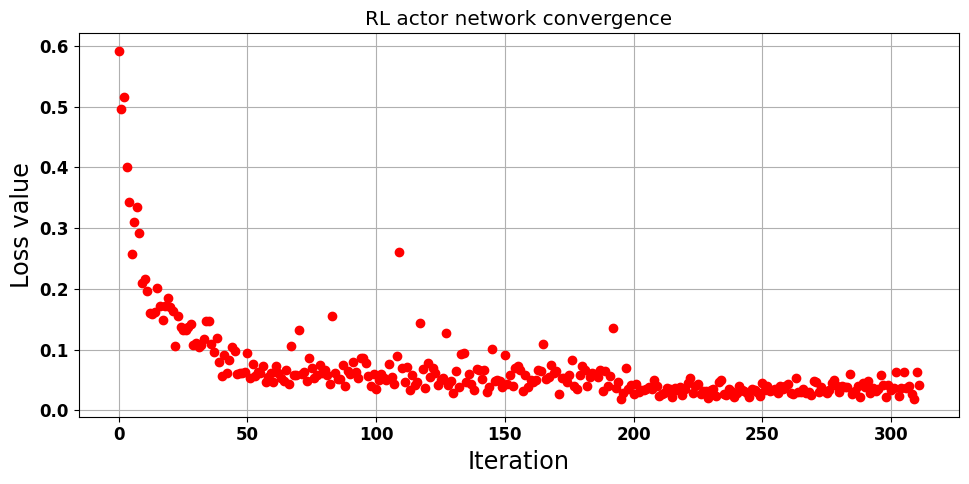

KeyboardInterrupt: 

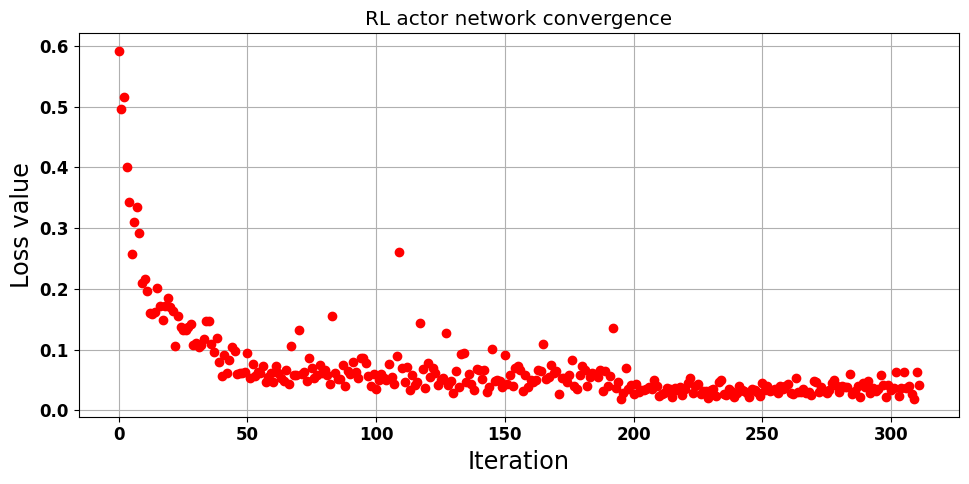

In [50]:
network = FCNetwork(env, layers=[20,20])
LR = 1e-3
cql_alpha_val = 0.3
weights = None
print (weighting_only)
plt.rcParams.update({'font.size': 12, "font.weight": "bold", 'axes.labelsize': 'x-large'})
fig,axs = plt.subplots(1,1,figsize=(10,5))
axs.set_xlabel('Iteration')
axs.set_ylabel('Loss value')
axs.set_title('RL actor network convergence')
plt.tight_layout()
csv_file_name = 'training_results.csv'
OUT_DIR = './trained_models'
output_file_path = os.path.join(OUT_DIR, csv_file_name)
preferences = w_batch_line
# pref_pool = np.concatenate(preferences, axis=0) 
initial_state = {
       'model_state_dict': network.state_dict(),
       'epoch': 0,  # Starting epoch
   }


with open(output_file_path, 'w', newline='') as csvfile:
    csv_writer = csv.writer(csvfile)
    trained_net = conservative_q_iteration(env, network, fig, axs,
                                        num_itrs=1000, discount=0.9, cql_alpha=cql_alpha_val,
                                        weights=weights, render=False,
                                        sampled=not(weighting_only),
                                        training_dataset=training_dataset_loaded,log_file=csv_writer,learning_rate=LR,
                                        preference = preferences, interpolators = interpolators, w_batch_interp=w_batch_interp, args=args)


torch.save(initial_state, f'./{OUT_DIR}/initial_state_all_preferences_{cql_alpha_val}_{LR}.pth')
fig.savefig(f'./{OUT_DIR}/Q-value_convergence.pdf')


In [ ]:
def compress_results_folder(results_dir,current_time,cql_alpha,LR):
    tar_file_name = f'{results_dir}/training_results_{current_time}_all_preference_{cql_alpha}_{LR}.tar'
    
    # Create a tar file
    with tarfile.open(tar_file_name, 'w') as tar:
        # Iterate through the files in the results directory
        for item in os.listdir(results_dir):
            if item.endswith(('.pth', '.csv', '.pdf')):
                item_path = os.path.join(results_dir, item)
                # Check if it's a file (not a directory)
                # if os.path.isfile(item_path):
                tar.add(item_path, arcname=item)  # Add file to tar
                os.remove(item_path)

    print(f"Compressed files into {tar_file_name}")

# Specify the results directory


In [ ]:


torch.save(trained_net.state_dict(), f'{OUT_DIR}/trained_network_weights_{current_time}_all_preference_{application_name}_{cql_alpha_val}_{LR}.pth')  # Save the model weights
compress_results_folder(OUT_DIR,current_time,cql_alpha_val,LR)
print("Trained weights have been saved to 'trained_network_weights.pth'")



Compressed files into ./trained_models/training_results_20250929_133448_all_preference_0.3_0.001.tar
Trained weights have been saved to 'trained_network_weights.pth'
